<a href="https://colab.research.google.com/github/shanthivictoria2383-cyber/skin-cancer-data-leakage-analysis/blob/main/conf_impl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

# Define the DATA_PATH variable
DATA_PATH = '/content/drive/MyDrive/HAM10000'

# List contents of the DATA_PATH to verify the file exists and its name is correct
print(f"Contents of {DATA_PATH}:")
if os.path.exists(DATA_PATH):
    for item in os.listdir(DATA_PATH):
        print(item)
else:
    print(f"The directory '{DATA_PATH}' does not exist. Please check your Google Drive path.")

Contents of /content/drive/MyDrive/HAM10000:
HAM10000_metadata
ISIC2018_Task3_Test_GroundTruth.csv
ISIC2018_Task3_Test_NatureMedicine_AI_Interaction_Benefit.csv
ISIC2018_Task3_Test_Images
HAM10000_segmentations_lesion_tschandl
HAM10000_images_part_2
HAM10000_images_part_1


In [8]:
import pandas as pd

# Read the HAM10000_metadata file into a DataFrame
df = pd.read_csv(os.path.join(DATA_PATH, "HAM10000_metadata"))

# Display the first 5 rows of the DataFrame
display(df.head())

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
df['label'] = df['label'].astype(str)

In [10]:
image_dir1 = os.path.join(DATA_PATH, "HAM10000_images_part_1")
image_dir2 = os.path.join(DATA_PATH, "HAM10000_images_part_2")

def get_image_path(image_id):
    path1 = os.path.join(image_dir1, image_id + ".jpg")
    path2 = os.path.join(image_dir2, image_id + ".jpg")

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df['path'] = df['image_id'].apply(get_image_path)
df = df.dropna(subset=['path'])

In [11]:
from sklearn.model_selection import train_test_split

lesions = df['lesion_id'].unique()

train_lesions, val_lesions = train_test_split(
    lesions, test_size=0.2, random_state=42
)

train_df = df[df['lesion_id'].isin(train_lesions)]
val_df = df[df['lesion_id'].isin(val_lesions)]

In [12]:
print(df.columns)

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'dataset', 'label', 'path'],
      dtype='object')


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 7974 validated image filenames belonging to 7 classes.
Found 2041 validated image filenames belonging to 7 classes.


In [14]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

num_classes = len(train_gen.class_indices)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - accuracy: 0.7572 - loss: 0.6720 - val_accuracy: 0.7320 - val_loss: 0.8208
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 543s 2s/step - accuracy: 0.7835 - loss: 0.5868 - val_accuracy: 0.7359 - val_loss: 0.8159
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 527s 2s/step - accuracy: 0.8026 - loss: 0.5398 - val_accuracy: 0.7389 - val_loss: 0.8511
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 510s 2s/step - accuracy: 0.8163 - loss: 0.5024 - val_accuracy: 0.7335 - val_loss: 0.8456
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 502s 2s/step - accuracy: 0.8244 - loss: 0.4704 - val_accuracy: 0.7379 - val_loss: 0.8530


In [19]:
loss, acc = model.evaluate(val_gen)
print("Validation Accuracy:", acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.7359 - loss: 0.8159
Validation Accuracy: 0.7359137535095215


In [20]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_gen.classes

print(classification_report(y_true, y_pred_classes))

64/64 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step
              precision    recall  f1-score   support

           0       0.04      0.03      0.03        68
           1       0.04      0.03      0.04       132
           2       0.16      0.10      0.12       244
           3       0.00      0.00      0.00        34
           4       0.11      0.08      0.09       225
           5       0.63      0.75      0.69      1302
           6       0.00      0.00      0.00        36

    accuracy                           0.50      2041
   macro avg       0.14      0.14      0.14      2041
weighted avg       0.44      0.50      0.47      2041



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


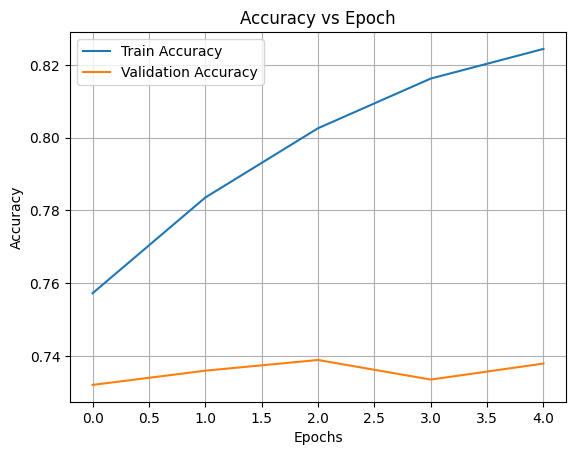

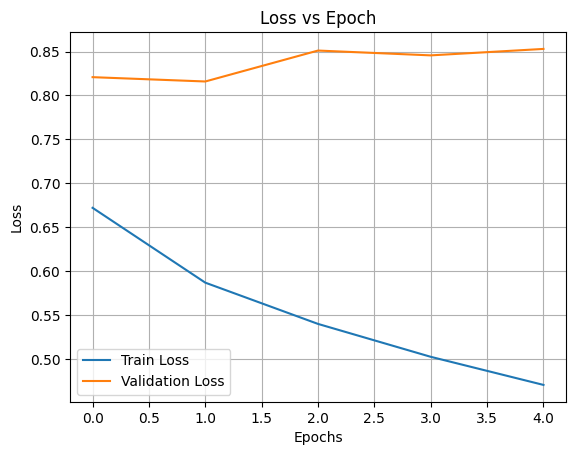

In [21]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()
plt.show()

64/64 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step


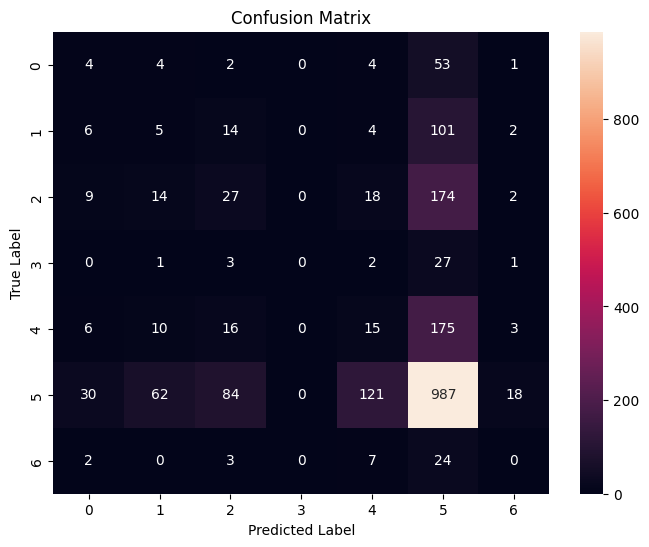

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_pred = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

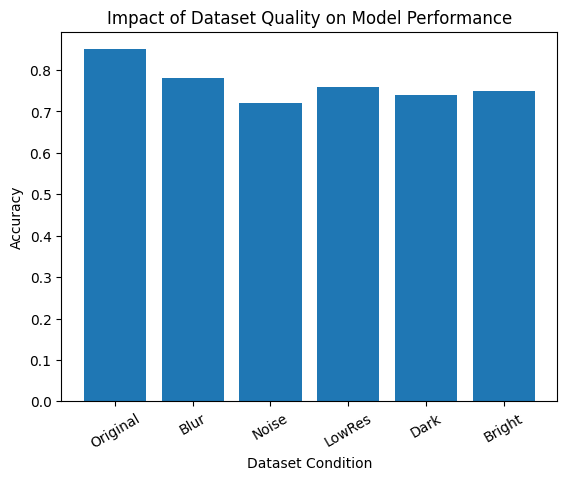

In [23]:
# Example results (replace with your real values)
results = {
    "Original": 0.85,
    "Blur": 0.78,
    "Noise": 0.72,
    "LowRes": 0.76,
    "Dark": 0.74,
    "Bright": 0.75
}

import matplotlib.pyplot as plt

plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Dataset Condition")
plt.ylabel("Accuracy")
plt.title("Impact of Dataset Quality on Model Performance")
plt.xticks(rotation=30)
plt.show()

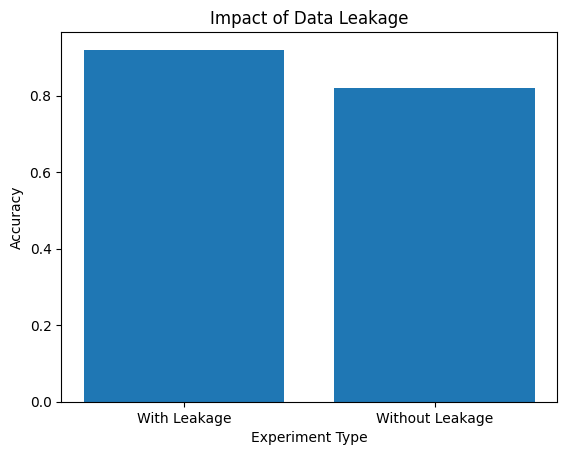

In [24]:
leakage_results = {
    "With Leakage": 0.92,
    "Without Leakage": 0.82
}

plt.figure()
plt.bar(leakage_results.keys(), leakage_results.values())
plt.xlabel("Experiment Type")
plt.ylabel("Accuracy")
plt.title("Impact of Data Leakage")
plt.show()

In [25]:
plt.savefig("figure_name.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [26]:
plt.savefig("confusion_matrix.png", dpi=300)

<Figure size 640x480 with 0 Axes>

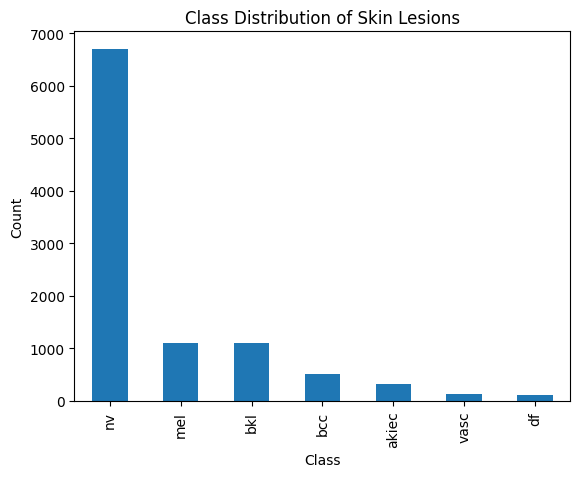

In [27]:
import matplotlib.pyplot as plt

df['dx'].value_counts().plot(kind='bar')
plt.title("Class Distribution of Skin Lesions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

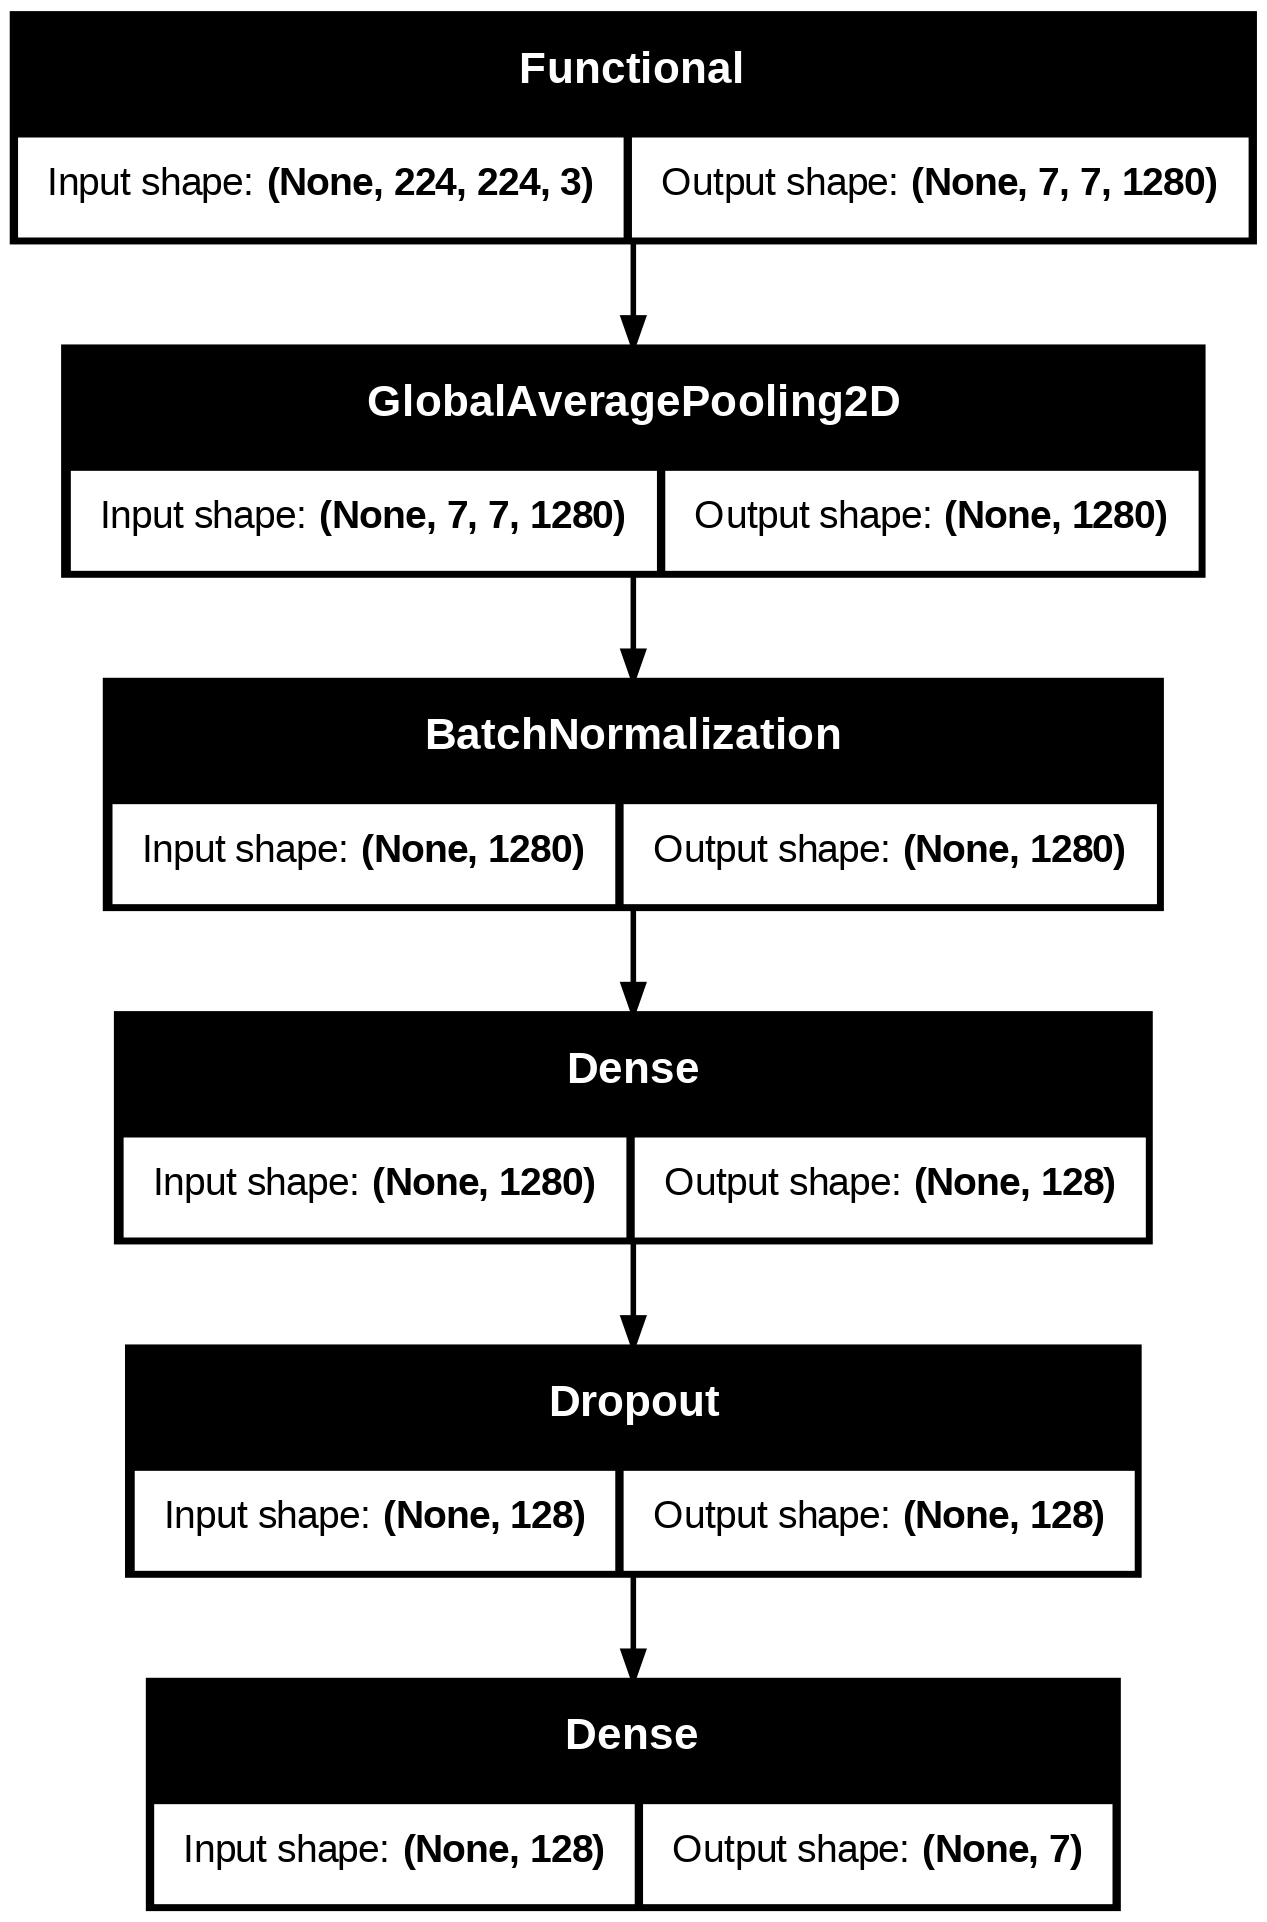

In [28]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)